In [1]:
import pandas as pd
import json

In [3]:
data_file = "../outputs/base_vs_instruct_analysis/report/processed_phase1.json"

# "../data/base_vs_instruct_oracle_V4.2.json"

In [4]:
def create_input_prompt_prefix(task_prompt, test_list, mode = "base"):
    prompt = (
            "You are an expert Python programmer, and here is your task: "
            f"{task_prompt} Your code should pass these tests:\n\n"
            + "\n".join(test_list) + "\nWrite your code below starting with \"```python\" and ending with \"```\".\n```python\n"
        )
    if mode == "instruct":
        prompt = (
            "You are an expert Python programmer, and here is your task: "
            f"{task_prompt} Your code should pass these tests:\n\n"
            + "\n".join(test_list) + "\nWrite your code, without docstrings, below starting with \"```python\" and ending with \"```\".\n```python\n"
        )
    
    return prompt

In [5]:
import ast

class Normalizer(ast.NodeTransformer):
    def __init__(self):
        self.var_map = {}
        self.func_map = {}
        self.class_map = {}
        self.counter = 0

    def _rename(self, name, mapping):
        if name not in mapping:
            mapping[name] = f"id_{len(mapping)}"
        return mapping[name]

    def visit_Name(self, node):
        node.id = self._rename(node.id, self.var_map)
        return node

    def visit_arg(self, node):
        node.arg = self._rename(node.arg, self.var_map)
        return node

    def visit_FunctionDef(self, node):
        node.name = self._rename(node.name, self.func_map)
        self.generic_visit(node)
        return node

    def visit_ClassDef(self, node):
        node.name = self._rename(node.name, self.class_map)
        self.generic_visit(node)
        return node

def normalize(code):
    try:
        tree = ast.parse(code)
        normalized = Normalizer().visit(tree)
        return ast.dump(normalized, annotate_fields=True, include_attributes=False)
    except:
        return None

In [6]:
def check_if_abstract_tree_same(base_response, instruct_response):
    return normalize(base_response) == normalize(instruct_response)

In [7]:
import difflib

def similarity(code1, code2):
    return difflib.SequenceMatcher(None, code1, code2).ratio()

In [11]:
sample_base_response = "def sum_series(n):\n    return n - 2 * (n // 2)"
sample_instruct_response = "def sum_series(n):\n  total = 0\n  for i in range(n // 2):\n    total += n - 2 * i\n  return total\n"

In [12]:
def _extract_code_part(input_prefix_text, suffix_text):
    try:
        full_text = input_prefix_text + suffix_text
        return "def" + full_text.split("```python\n")[-1].split("def")[1]
    except:
        # print("Could not extract code from ", suffix_text)
        return None

def _ascertain_two_codes_similar(expected_code, steered_code, threshold = 0.95, verbose = False):
    normalized_expected_code = normalize(expected_code)
    normalized_steered_code = normalize(steered_code)
    if verbose:
        print("Check for full similarity", normalized_expected_code == normalized_steered_code)
        print("Check for whether crosses threshold", similarity(normalized_expected_code, normalized_steered_code))
    return normalized_expected_code == normalized_steered_code or similarity(normalized_expected_code, normalized_steered_code) > threshold

In [13]:
_ascertain_two_codes_similar(sample_base_response, sample_instruct_response)

False

In [14]:
sample_base_response = "def sum_series(n):\n    return n - 2 * func(n - 2)"
alt_base_response = """def sum_series(m):\n    return m ** 0.5 - 2 * func (m // 2)"""
_ascertain_two_codes_similar(sample_base_response, alt_base_response, verbose = True)

Check for full similarity False
Check for whether crosses threshold 0.9375


False

In [15]:
sample_base_response = """
def sum_series(n):
    sum = 0
    for i in range(5):
        sum += i
    return sum
"""
alt_base_response = """
def sum_ser(b):
    s = 0
    for i in range(0, 5):
        s = s + i
    return s
"""
_ascertain_two_codes_similar(sample_base_response, alt_base_response, verbose = True)

Check for full similarity False
Check for whether crosses threshold 0.6421232876712328


False

In [16]:
from zss import simple_distance, Node

def to_zss(node):
    if not isinstance(node, ast.AST):
        return None
    children = []
    for f in node._fields:
        value = getattr(node, f)
        if isinstance(value, list):
            for child in value:
                if isinstance(child, ast.AST):
                    children.append(to_zss(child))
        elif isinstance(value, ast.AST):
            children.append(to_zss(value))
    return Node(node.__class__.__name__, children=children)

In [17]:
def normalize_ast(code):
    try:
        tree = ast.parse(code)
        norm = Normalizer().visit(tree)
        ast.fix_missing_locations(norm)
        return norm
    except Exception as e:
        return None

In [18]:
def print_ast(node, indent=""):
    print(indent + node.__class__.__name__)
    for child in ast.iter_child_nodes(node):
        print_ast(child, indent + "  ")

def visualize_ast(code):
    tree = ast.parse(code)
    print_ast(tree)

In [19]:
def _check_zss_sim(code1, code2, threshold = 4, verbose = False):
    node1 = normalize_ast(code1)
    node2 = normalize_ast(code2)
    distance = simple_distance(to_zss(node1), to_zss(node2))
    if verbose:
        print("Check for distance", distance)
    return distance <= 4

In [20]:
sample_base_response = "def sum_series(n):\n    return n - 2 * (n // 2)"
sample_instruct_response = "def sum_series(n):\n  total = 0\n  for i in range(n // 2):\n    total += n - 2 * i\n  return total\n"
_check_zss_sim(sample_base_response, sample_instruct_response, verbose = True)

Check for distance 25.0


False

In [21]:
visualize_ast(sample_base_response)

Module
  FunctionDef
    arguments
      arg
    Return
      BinOp
        Name
          Load
        Sub
        BinOp
          Constant
          Mult
          BinOp
            Name
              Load
            FloorDiv
            Constant


In [22]:
from zss import simple_distance, Node

def _check_zss_sim_with_ops(code1, code2, threshold=4, verbose=False):
    node1 = normalize_ast(code1)
    node2 = normalize_ast(code2)
    
    tree1 = to_zss(node1)
    tree2 = to_zss(node2)
    
    # Get distance with operations
    result = simple_distance(
        tree1, tree2,
        get_children=lambda n: n.children if hasattr(n, 'children') else [],
        get_label=lambda n: n.label if hasattr(n, 'label') else str(type(n).__name__),
        label_dist=lambda a, b: 0 if a == b else 1,
        return_operations=True
    )
    
    if isinstance(result, tuple):
        dist, ops = result
    else:
        dist = result
        ops = []
    
    if verbose:
        print(f"Distance: {dist}\n")
        
        for i, op in enumerate(ops):
            op_type = str(type(op).__name__)
            
            if hasattr(op, 'arg1') and hasattr(op, 'arg2'):
                node1 = getattr(op.arg1, 'label', op.arg1)
                node2 = getattr(op.arg2, 'label', op.arg2)
                print(f"{i:3d}: {op_type:8s} {node1} -> {node2}")
            elif hasattr(op, 'arg1'):
                node1 = getattr(op.arg1, 'label', op.arg1)
                print(f"{i:3d}: {op_type:8s} {node1}")
            elif hasattr(op, 'arg2'):
                node2 = getattr(op.arg2, 'label', op.arg2)
                print(f"{i:3d}: {op_type:8s} {node2}")
    
    return dist <= threshold, ops

In [23]:
_check_zss_sim_with_ops(sample_base_response, alt_base_response)

(False,
 [<Operation Match>,
  <Operation Match>,
  <Operation Insert>,
  <Operation Insert>,
  <Operation Insert>,
  <Operation Insert>,
  <Operation Insert>,
  <Operation Match>,
  <Operation Match>,
  <Operation Update>,
  <Operation Match>,
  <Operation Insert>,
  <Operation Update>,
  <Operation Insert>,
  <Operation Match>,
  <Operation Match>,
  <Operation Update>,
  <Operation Update>,
  <Operation Insert>,
  <Operation Match>,
  <Operation Insert>,
  <Operation Remove>,
  <Operation Update>,
  <Operation Insert>,
  <Operation Insert>,
  <Operation Insert>,
  <Operation Remove>,
  <Operation Match>,
  <Operation Match>])

In [24]:
def _get_zss_sim(code1, code2):
    node1 = normalize_ast(code1)
    node2 = normalize_ast(code2)
    try:
        distance = simple_distance(to_zss(node1), to_zss(node2))
        return distance
    except:
        # print("got exception for ", code1, code2)
        return 30

In [25]:
sample_base_response = "def tetrahedral_number(n):\n    return (n * (n + 1) * (n + 2)) / 6\n"
sample_instruct_response = "def tetrahedral_number(n):\n  if n == 1:\n    return 1\n  return (n * (n + 1) * (n + 2)) // 6\n"

In [26]:
_get_zss_sim(sample_base_response, sample_instruct_response)

9.0

In [21]:
def _get_all_valid_steers(file, y_ms):
    with open(file, "r") as f:
        data = json.load(f)
    meta_file = file.replace("steering_results.json", "metadata.json").replace("earliest_position.json", "metadata.json")
    with open(meta_file, "r") as f:
        meta_data = json.load(f)
        # print(meta_data.keys())
        input_prefix = meta_data["input_prefix_text"]
    all_valid_steers = []
    for cand, val in data.items():
        if cand in y_ms:
            for steer in val["steered"]:
                if "decoded_text" in steer:
                    decoded_text = steer["decoded_text"]
                    extracted_code = _extract_code_part(input_prefix, decoded_text)
                    all_valid_steers.append(extracted_code)
    
    return all_valid_steers

In [22]:
def obtain_min(objects, scores):
    objects, scores = zip(*sorted(zip(objects, scores), key=lambda x: x[1]))
    objects = list(objects)
    scores = list(scores)
    return objects[0], scores[0]

def _curate_entry(base, steer, complement, idx, tag = "base to instruct"):
    return {
        "model_code": base,
        "steered_code": steer,
        "complement_code": complement,
        "entry_idx": idx,
        "tag": tag,
        "label": False
    }

In [23]:
with open(data_file, "r") as f:
    selected_data = json.load(f)

In [26]:
import glob

def _get_closest_entry(all_steering_files: list[str], complement_code: str, yms: list[str]):
    all_steers = [_get_all_valid_steers(steering_file, yms) for steering_file in all_steering_files]
    all_steers = [x for sub in all_steers for x in sub]
    all_steer_zss = [_get_zss_sim(code, complement_code) for code in all_steers]
    if len(all_steers) > 0:
        closest_steer, _ = obtain_min(all_steers, all_steer_zss)
        return closest_steer
    else:
        return None

sweep_entries = []

for idx, entry in enumerate(selected_data):
    # ym_bases, ym_instructs = entry["base_plans"], entry["instruct_plans"]
    actual_base_code, actual_instruct_code = entry["model_output"], entry["instruct_code"]
    # if ym_bases is not None and ym_instructs is not None and len(ym_bases) > 0 and len(ym_instructs) > 0:
    #     base_token_files = glob.glob(f"../outputs/all_scale/base/prompt_{idx}/token_*/steering_results.json")
    #     instruct_token_files = glob.glob(f"../outputs/all_scale/instruct/prompt_{idx}/token_*/steering_results.json")
    #     closest_base_steer = _get_closest_entry(base_token_files, actual_instruct_code, ym_bases)
    #     closest_instruct_steer = _get_closest_entry(instruct_token_files, actual_base_code, ym_instructs)
    #     entry_base = _curate_entry(actual_base_code, closest_base_steer, actual_instruct_code, idx)
    #     sweep_entries.append(entry_base)
    #     entry_instruct = _curate_entry(actual_instruct_code, closest_instruct_steer, actual_base_code, idx, tag = "instruct to base")
    #     sweep_entries.append(entry_instruct)

    try:    
        ym_bases_e, ym_instructs_e = entry["base_plans_e"], entry["instruct_plans_e"]
    except:
        continue
    if ym_bases_e is not None and ym_instructs_e is not None and len(ym_bases_e) > 0 and len(ym_instructs_e) > 0:
        base_token_files_e = glob.glob(f"../outputs/all_scale/base/prompt_{idx}/token_*/earliest_position.json")
        instruct_token_files_e = glob.glob(f"../outputs/all_scale/instruct/prompt_{idx}/token_*/earliest_position.json")
        closest_base_steer_e = _get_closest_entry(base_token_files_e, actual_instruct_code, ym_bases_e)
        closest_instruct_steer_e = _get_closest_entry(instruct_token_files_e, actual_base_code, ym_instructs_e)
        entry_base_e = _curate_entry(actual_base_code, closest_base_steer_e, actual_instruct_code, idx, tag = "base to instruct (e)")
        sweep_entries.append(entry_base_e)
        entry_instruct_e = _curate_entry(actual_instruct_code, closest_instruct_steer_e, actual_base_code, idx, tag = "instruct to base (e)")
        sweep_entries.append(entry_instruct_e)
    
    print(f"done with idx: {idx}")

done with idx: 0
done with idx: 1
done with idx: 2
done with idx: 3
done with idx: 4
done with idx: 5
done with idx: 6
done with idx: 7
done with idx: 8
done with idx: 9
done with idx: 10
done with idx: 11
done with idx: 12
done with idx: 13
done with idx: 14
done with idx: 15
done with idx: 16
done with idx: 17
done with idx: 18
done with idx: 19
done with idx: 20
done with idx: 21
done with idx: 22
done with idx: 23
done with idx: 24
done with idx: 25
done with idx: 26
done with idx: 27
done with idx: 28
done with idx: 29
done with idx: 30
done with idx: 31
done with idx: 32
done with idx: 33
done with idx: 34
done with idx: 35
done with idx: 36
done with idx: 37
done with idx: 38
done with idx: 39
done with idx: 40
done with idx: 41
done with idx: 42
done with idx: 43
done with idx: 44
done with idx: 45
done with idx: 46
done with idx: 47
done with idx: 48
done with idx: 49
done with idx: 50
done with idx: 51
done with idx: 52
done with idx: 53
done with idx: 54
done with idx: 55
do

In [27]:
def _steered_answer_goes_closer_to_complement(current_generation, steered_generation, complement_generation, gamma = 0.5, lamda = 8):
    try:
        current_code = normalize_ast(current_generation)
        steered_code = normalize_ast(steered_generation)
        complement_code = normalize_ast(complement_generation)
        d_orig = simple_distance(to_zss(current_code), to_zss(complement_code))
        d_new = simple_distance(to_zss(steered_code), to_zss(complement_code))
        if isinstance(d_orig, float) and isinstance(d_new, float):
            d_ratio = (d_new + 1) / (d_orig + 1)
            # print("d_ratio", d_ratio, "d_new", d_new)
            return d_ratio <= gamma and d_new <= lamda, d_ratio, d_new
    except:
        pass
    return False, 1, 30

In [28]:
for _, entry in enumerate(sweep_entries):
    calculated_label, d_ratio, d_new = _steered_answer_goes_closer_to_complement(entry["model_code"], entry["steered_code"], entry["complement_code"])
    entry["label"] = calculated_label    

In [29]:
sweep_entries[0]

{'model_code': 'def is_undulating(n):\n    if n < 0:\n        return False\n    if n == 1:\n        return True\n    if n % 2 == 0:\n        return is_undulating(n // 2)\n    return is_undulating(n - 1)\n',
 'steered_code': 'def is_undulating(n):\n    if len(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(int(str(',
 'complement_code': 'def is_undulating(number):\n  if number < 0:\n    return False\n  return all(number % 10 != number // 10 + 1 for i in range(len(str(number))))\n',
 'entry_idx': 44,
 'tag': 'base to instruct (e)',
 'label': False}

In [30]:
for entry in sweep_entries:
    entry["label"] = bool(entry["label"])    

In [32]:
# with open("../data/base_vs_instruct_A_tags2.json", "w") as f:
#     json.dump(sweep_entries, f, indent = 2)

In [34]:
### Load the tag data to this oracle.

def _match_sweep(e, tag, idx):
    return e["tag"] == tag and e["entry_idx"] == idx

def _make_entry(e, tag, idx):
    sweeped = next(x for x in sweep_entries if _match_sweep(x, tag, idx))
    e[tag] = {
        "code": sweeped["steered_code"],
        "label": sweeped["label"]
    }


for idx, entry in enumerate(selected_data):
    # ym_bases, ym_instructs = entry["base_plans"], entry["instruct_plans"]

    # if ym_bases is not None and ym_instructs is not None and len(ym_bases) > 0 and len(ym_instructs) > 0:
    #     _make_entry(entry, "base to instruct", idx)
    #     _make_entry(entry, "instruct to base", idx)
    
    try:
        ym_bases_e, ym_instructs_e = entry["base_plans_e"], entry["instruct_plans_e"]
    except:
        continue
    if ym_bases_e is not None and ym_instructs_e is not None and len(ym_bases_e) > 0 and len(ym_instructs_e) > 0:
        _make_entry(entry, "base to instruct (e)", idx)
        _make_entry(entry, "instruct to base (e)", idx)

In [35]:
selected_data[1]

{'source_file': 'Benchmark Questions Verification V2.ipynb',
 'task_id': 3,
 'prompt': 'Write a python function to identify non-prime numbers.',
 'code': 'import math\ndef is_not_prime(n):\n    result = False\n    for i in range(2,int(math.sqrt(n)) + 1):\n        if n % i == 0:\n            result = True\n    return result',
 'test_imports': [],
 'test_list': ['assert is_not_prime(2) == False',
  'assert is_not_prime(10) == True',
  'assert is_not_prime(35) == True',
  'assert is_not_prime(37) == False'],
 'instruct_code': 'def is_not_prime(n):\n    if n <= 1:\n        return True\n    for i in range(2, int(n**0.5) + 1):\n        if n % i == 0:\n            return True\n    return False\n',
 'model_output': 'def is_not_prime(number):\n    if number == 2:\n        return False\n    if number == 1:\n        return True\n    if number % 2 == 0:\n        return False\n    for i in range(3, number, 2):\n        if number % i == 0:\n            return False\n    return True\n',
 'position_in

In [36]:
for entry in selected_data:
    if entry["base_pass"] == False and entry["instruct_pass"] == True and entry["base_plans_e"] is not None and len(entry["base_plans_e"]) > 0 and entry["instruct_plans_e"] is not None and len(entry["instruct_plans_e"]) > 0:
        tag = "A3"
        if entry["base to instruct (e)"]["label"] == True:
            tag = "A1"
        elif entry["instruct to base (e)"]["label"] == True:
            tag = "A2"
        entry["A_tag (e)"] = tag 

In [38]:
# for entry in selected_data:
#     if entry["base_pass"] == False and entry["instruct_pass"] == True and entry["base_plans"] is not None and len(entry["base_plans"]) > 0 and entry["instruct_plans"] is not None and len(entry["instruct_plans"]) > 0:
#         tag = "A3"
#         if entry["base to instruct"]["label"] == True:
#             tag = "A1"
#         elif entry["instruct to base"]["label"] == True:
#             tag = "A2"
#         entry["A_tag"] = tag 

In [39]:
# with open("../data/base_vs_instruct_oracle_V4.3.json", "w") as f:
#     json.dump(selected_data, f, indent = 2)

In [35]:
a1, a2, a3 = 0, 0, 0
for entry in selected_data:
    try:
        if entry['A_tag'] == 'A1':
            a1 += 1
        elif entry['A_tag'] == "A2":
            a2 += 1
        else:
            a3 += 1
    except:
        continue

print(f"a1: {a1}, a2: {a2}, a3: {a3}")

a1: 8, a2: 1, a3: 8


In [40]:
a1, a2, a3 = 0, 0, 0
for entry in selected_data:
    try:
        if entry['A_tag (e)'] == 'A1':
            a1 += 1
        elif entry['A_tag (e)'] == "A2":
            a2 += 1
        else:
            a3 += 1
    except:
        continue

print(f"a1: {a1}, a2: {a2}, a3: {a3}")

a1: 0, a2: 1, a3: 5


In [41]:
len(selected_data)

392

In [42]:
cc = 0
for entry in selected_data:
    if entry["base_pass"] == False and entry["instruct_pass"] == True and entry["base_plans_e"] is not None and len(entry["base_plans_e"]) > 0 and entry["instruct_plans_e"] is not None and len(entry["instruct_plans_e"]) > 0:
        cc += 1

print(cc)

6


In [44]:
from matplotlib import pyplot as plt
import numpy as np

def _get_2x2_grid(selected_cases, with_e=False):
    suffix = "_e" if with_e else ""
    instruct_plan_base_no_plan = []
    base_plan_instruct_no_plan = []
    both_plans = []
    no_plans = []

    for entry in selected_cases:
        base_planning, instruct_planning = False, False

        if entry.get("base_plans" + suffix) and len(entry["base_plans" + suffix]) > 0:
            base_planning = True
        elif entry.get("base_cs" + suffix) is True:
            continue

        if entry.get("instruct_plans" + suffix) and len(entry["instruct_plans" + suffix]) > 0:
            instruct_planning = True
        elif entry.get("instruct_cs" + suffix) is True:
            continue

        if base_planning:
            if instruct_planning:
                both_plans.append(entry)
            else:
                base_plan_instruct_no_plan.append(entry)
        elif instruct_planning:
            instruct_plan_base_no_plan.append(entry)
        else:
            no_plans.append(entry)

    return {
        "Both": both_plans,
        "Only instruct": instruct_plan_base_no_plan,
        "Only base": base_plan_instruct_no_plan,
        "None": no_plans,
    }


def compute_4x4_counts(data, with_e=False):
    quadrants = [
        ((True, True), (0, 0), "Instruct Pass / Base Pass"),
        ((True, False), (0, 2), "Instruct Pass / Base Fail"),
        ((False, True), (2, 0), "Instruct Fail / Base Pass"),
        ((False, False), (2, 2), "Instruct Fail / Base Fail"),
    ]

    counts = np.zeros((4, 4), dtype=int)

    for (ip, bp), (r0, c0), _title in quadrants:
        selected = [
            case for case in data if case.get("instruct_pass") == ip and case.get("base_pass") == bp
        ]
        buckets = _get_2x2_grid(selected, with_e=with_e)

        counts[r0 + 0, c0 + 0] = len(buckets["Both"])
        counts[r0 + 0, c0 + 1] = len(buckets["Only instruct"])
        counts[r0 + 1, c0 + 0] = len(buckets["Only base"])
        counts[r0 + 1, c0 + 1] = len(buckets["None"])

    return counts


def plot_4x4_plan_grid(data, with_e=False, ax=None, cmap="Blues", title=None):
    counts = compute_4x4_counts(data, with_e=with_e)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    else:
        fig = ax.figure

    im = ax.imshow(counts, cmap=cmap)

    vmax = counts.max() if counts.size else 1
    for r in range(4):
        for c in range(4):
            ax.text(
                c,
                r,
                str(counts[r, c]),
                ha="center",
                va="center",
                fontsize=12,
                color="white" if counts[r, c] > 0.6 * vmax else "black",
            )

    ax.set_xticks(np.arange(-0.5, 4, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=1)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    ax.axhline(1.5, linewidth=3)
    ax.axhline(3.5, linewidth=3)
    ax.axvline(1.5, linewidth=3)
    ax.axvline(3.5, linewidth=3)

    ax.axhline(-0.5, linewidth=3)
    ax.axvline(-0.5, linewidth=3)

    inner_labels = {
        (0, 0): "Both Plans",
        (0, 1): "Only Instruct Plans",
        (1, 0): "Only Base Plans",
        (1, 1): "None Plan",
    }
    for r0, c0 in [(0, 0), (0, 2), (2, 0), (2, 2)]:
        for (dr, dc), lab in inner_labels.items():
            r = r0 + dr
            c = c0 + dc
            ax.text(c, r - 0.32, lab, ha="center", va="center", fontsize=8)

    ax.text(0.5, -0.95, "Base Pass", ha="center", va="center", fontsize=14)
    ax.text(2.5, -0.95, "Base Fail", ha="center", va="center", fontsize=14)

    ax.text(-0.95, 0.5, "Instruct Pass", ha="center", va="center", fontsize=14, rotation=90)
    ax.text(-0.95, 2.5, "Instruct Fail", ha="center", va="center", fontsize=14, rotation=90)

    quad_titles = {
        (0.5, 0.5): "IP / BP",
        (0.5, 2.5): "IP / BF",
        (2.5, 0.5): "IF / BP",
        (2.5, 2.5): "IF / BF",
    }
    for (y, x), t in quad_titles.items():
        ax.text(x, y, t, ha="center", va="center", fontsize=12, fontweight="bold")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
    ax.set_xlim(-1.2, 3.5)
    ax.set_ylim(3.5, -1.2)
    if title is None:
        title = "4x4 Grid: Pass/Fail quadrants x Planning categories"
    ax.set_title(title, fontsize=14)
    return ax

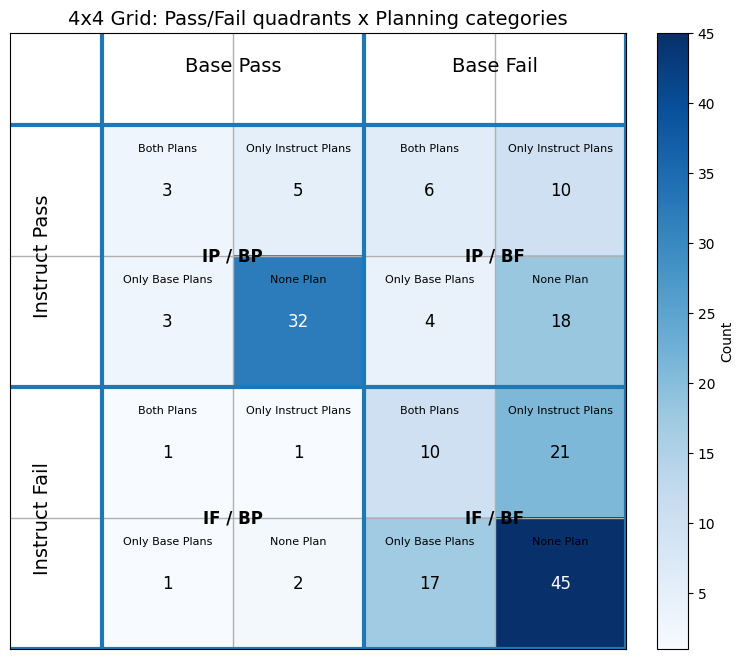

In [45]:
ax = plot_4x4_plan_grid(selected_data, with_e=True)
plt.show()